# Dataset sul Traffico di Rete

Il dataset che useremo in questa esercitazione contiene caratteristiche estratte da sessioni di traffico di rete, progettate per l'analisi e il rilevamento di malware basato sul comportamento della rete. Le caratteristiche sono organizzate in diverse categorie funzionali.

## Categorie principali di caratteristiche

### Informazioni sulla sessione
- **Informazioni temporali**: `start`, `duration`, `cap_date`, `daysTime`, `weekDay`
- **Informazioni di connessione**: Indirizzi IP e porte (`...ip`, `...port`)
- **Etichette**: `label`, `labelSS` (classificazione del malware)

### Metriche TCP/IP
- **Statistiche pacchetti**: Conteggio pacchetti (`packets_...`), dimensioni (`packetsize...`), rapporti (`packetsAB_ratio`)
- **Flag TCP**: Pacchetti ACK (`ack_...`), PUSH (`push_...`), RESET (`reset_...`), URG (`urg_...`)
- **Tempi di arrivo**: Tempi tra pacchetti (`packetinterarrivel_...`)
- **Time-to-live**: Valori TTL per pacchetti client/server (`ttl_...`, `ttlA...`, `ttlB...`)
- **Analisi TCP**: Pacchetti persi, ritrasmessi (`tcpanalysis...`)
- **Bytes trasferiti**: Totali e rapporti (`bytes_...`, `bytesAB_ratio`)

### Protocollo HTTP
- **Richieste HTTP**: Metodi GET/POST (`http_GET`, `http_POST`), conteggi (`httpcount...`)
- **Bytes HTTP**: Dimensioni richieste/risposte (`httpreqbytes_...`, `httprespbytes_...`)
- **Tempi HTTP**: Tempi di risposta (`httptime...`), tempi tra richiesta e risposta (`httpinterarrivel_...`)
- **Cookie**: Conteggio e valori (`httpcookiecount`, `httpcookievalues_...`)
- **Host dominante**: URL, rank Alexa, tipo di browser (`httpdom...`)
- **Classificazione URL**: Identificatori per CDN, ad, cloud, ecc. (`iscdnhttp`, `isadhttp`, `iscloudhttp`, etc.)

### Protocollo DNS
- **Risposta DNS**: Conteggio indirizzi, risposte, flag (`dnscountaddresses`, `dns_flag`)
- **Hostname DNS**: Nome host, TTL (`dnshostname`, `dnsminttl`)
- **Tempi DNS**: Tempo di risposta (`dns_time`)
- **Rank Alexa**: Rank del server nella risposta DNS (`dns_alexaRank`)

### Protocollo SSL/TLS
- **Handshake SSL**: Durata (`sslhandshakeduration_...`)
- **Bytes SSL**: Bytes richiesta/risposta (`sslreqbytes_...`, `sslrespbytes_...`)
- **Certificati**: Conteggio, rapporti (`sslcountcertificates`, `sslratio...`)
- **Cifrari e algoritmi**: Conteggio cifrari supportati (`sslcountclient_...`, `sslcountserver_...`)
- **Versioni SSL**: Numero di versioni, versione dominante (`ssldomserver_ciphersuite`, `ssldomserver_compression`)

### Informazioni geografiche e di routing
- **ASN**: Numero di sistemi autonomi (`asn_...`)
- **Paesi**: Numero di paesi per client/server (`country_...`)


# Obiettivo
  Classificare un dispositivo come dispositivo di sicurezza o no. Vedi colonna `is_security_device`

In [50]:
import pandas as pd
df = pd.read_csv('../datasets/iot_device_binary_transformed.csv')

### Stampiamo le colonne

In [51]:
df.columns

Index(['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio',
       'bytes_B', 'ds_field_A', 'ds_field_B', 'duration',
       ...
       'suffix_is_co.il', 'suffix_is_com', 'suffix_is_com.sg',
       'suffix_is_else', 'suffix_is_empty_char_value',
       'suffix_is_googleapis.com', 'suffix_is_net', 'suffix_is_org',
       'suffix_is_unresolved', 'is_security_device'],
      dtype='str', length=298)

### Vediamo che tipologia di valori dobbiamo classificare

In [52]:
df["is_security_device"]

0      1
1      1
2      1
3      1
4      1
      ..
895    0
896    0
897    0
898    0
899    0
Name: is_security_device, Length: 900, dtype: int64

#### Abbiamo uni e zeri. Quindi indicano delle classi discrete
Vediamo se il dataset è bilanciato

In [53]:
df['is_security_device'].value_counts()

is_security_device
0    500
1    400
Name: count, dtype: int64

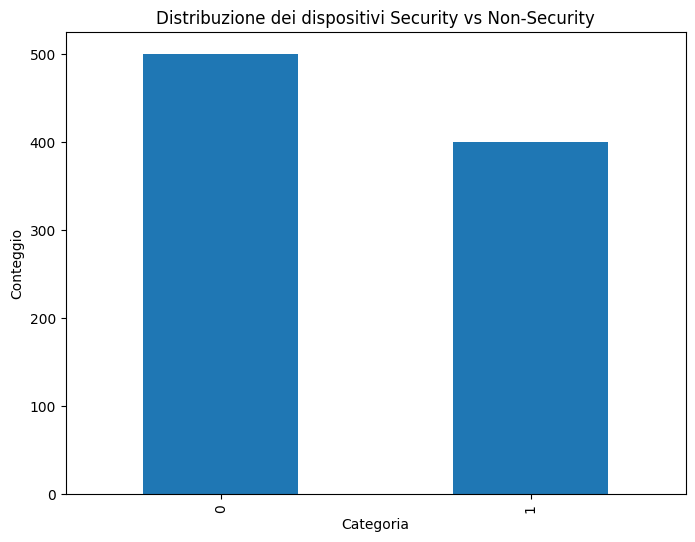

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df['is_security_device'].value_counts().plot(kind='bar')
plt.title('Distribuzione dei dispositivi Security vs Non-Security')
plt.xlabel('Categoria')
plt.ylabel('Conteggio')
plt.show()

In [55]:
# Verifica dei valori NaN
nan_counts = df.isna().sum()
print(f"Colonne con valori NaN:")
print(nan_counts[nan_counts > 0])

Colonne con valori NaN:
Series([], dtype: int64)


# Troppe feature, dobbiamo filtrare

### Metodo per filtrare: utilizzare la varianza

- rimuoviamo colonne costanti (varianza 0) o  quasi (varianza molto bassa) che danno poca informazione

Nessuna relazione con la feature target

Stiamo pulendo il dataset, non stiamo ancora facendo nessuna considerazione di utilità

## ATTENZIONE: Se le feature sono su scale diverse, alcune possono avere varianza alta solo perché hanno valori grandi, non perché sono più informative. Utilizzare questo metodo solo per ridurre feature quasi costanti

suffix_is_org                        0.0
suffix_is_net                        0.0
suffix_is_googleapis.com             0.0
http_cookie_values_entropy           0.0
http_cookie_values_var               0.0
http_cookie_values_stdev             0.0
subdomain_is_whp.hou9.cold.extweb    0.0
subdomain_is_www                     0.0
subdomain_is_feeds                   0.0
subdomain_is_h10141.www1             0.0
subdomain_is_img                     0.0
subdomain_is_whp.aus1.cold.extweb    0.0
B_port_is_9543                       0.0
subdomain_is_99sets                  0.0
subdomain_is_ccc                     0.0
B_port_is_8280                       0.0
is_img_http                          0.0
is_ad_http                           0.0
B_port_is_54975                      0.0
B_port_is_5223                       0.0
http_req_bytes_stdev                 0.0
http_req_bytes_var                   0.0
http_req_bytes_entropy               0.0
B_port_is_5222                       0.0
http_has_locatio

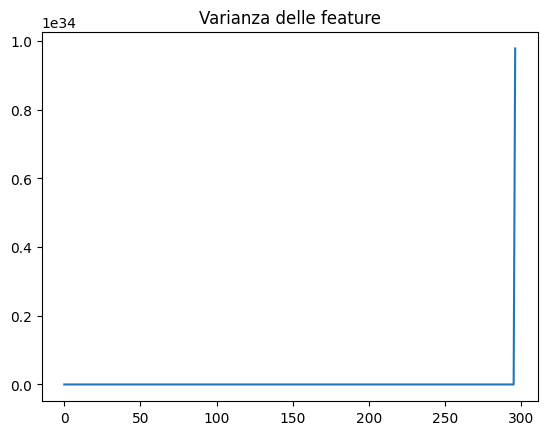

In [78]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['is_security_device'])
y = df['is_security_device']

# calcolo i valori di varianza e li ordiniamo dal più piccolo al più grande
variances = X.var().sort_values()
print(variances.head(30))   # le più basse

print(variances.tail(5))   # le più alte

plt.plot(variances.values)
plt.title("Varianza delle feature")
plt.show()

In [79]:
threshold = 0.1
selected_features = variances[variances > threshold].index
X_var = X[selected_features]

X_var

,subdomain_is_else,B_port_is_80,domain_is_else,http_count_req_content_type,is_http,http_count_user_agents,http_count_host,http_has_user_agent,http_has_resp_content_type,http_has_req_content_type,...,http_dom_host_alexaRank,http_time_min,http_time_firstQ,http_time_avg,http_time_median,http_time_thirdQ,http_time_max,ssl_dom_server_name_alexaRank,http_time_sum,http_time_var
0,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
1,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
2,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
3,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
4,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,139,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
896,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
897,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0
898,1,0,1,0,0,0,0,0,0,0,...,2147483647,0.0,0.0,0.0,0.0,0.0,0.0,1779,0.0,0.0


### Possiamo ora filtrare le colonne in base al modulo della correlazione

ttl_stdev                     0.563891
ttl_min                       0.523717
ttl_var                       0.504516
ttl_firstQ                    0.493652
B_port_is_8080                0.478091
reset_A                       0.476139
ttl_entropy                   0.472068
ds_field_B                    0.469486
suffix_is_empty_char_value    0.430691
packets_A_B_ratio             0.373072
domain_is_else                0.367310
B_port_is_80                  0.367310
http_req_bytes_avg            0.358941
http_req_bytes_firstQ         0.358941
http_req_bytes_median         0.358941
http_req_bytes_min            0.358941
http_req_bytes_max            0.358941
http_req_bytes_thirdQ         0.358941
http_count_user_agents        0.358561
http_has_user_agent           0.358561
dtype: float64


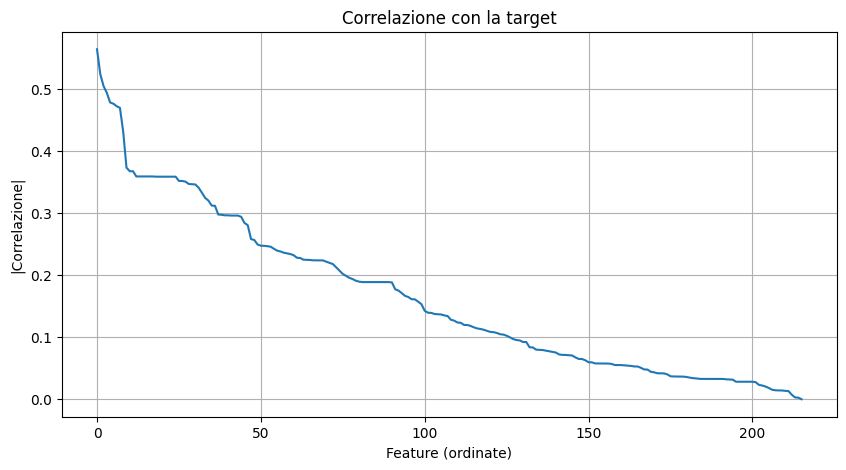

In [85]:
# Calcolo della correlazione tra ogni feature e la target
corr_with_target = X_var.corrwith(y)

# Prendo il valore assoluto (non mi interessa il segno)
corr_with_target = corr_with_target.abs()

# Ordino le feature dalla più correlata alla meno correlata
corr_with_target = corr_with_target.sort_values(ascending=False)

# Stampo le più importanti
print(corr_with_target.head(20))

plt.figure(figsize=(10,5))
plt.plot(corr_with_target.values)
plt.title("Correlazione con la target")
plt.xlabel("Feature (ordinate)")
plt.ylabel("|Correlazione|")
plt.grid(True)
plt.show()

In [90]:
# Definisco una soglia guardando il grafico
# threshold = 0.3

# Seleziono le feature con correlazione superiore alla soglia
# selected_features = corr_with_target[corr_with_target > threshold].index

# Creo il nuovo dataset filtrato
# X_corr = X_var[selected_features]

# Stampo quante feature sono rimaste
# print("Numero di feature dopo filtraggio per correlazione:", X_corr.shape[1])

# OPPURE
# Seleziono le top-k feature più correlate
top_k = 30

selected_features = corr_with_target.head(top_k).index

# Dataset finale
cleaned_df = X_var[selected_features]
# Aggiungo la variabile target
cleaned_df["is_security_device"] = y

# Stampo le dimensioni del nuovo dataframe
print(f"Dimensioni del nuovo DataFrame: {cleaned_df.shape}")

# Stampo il numero di feature selezionate (senza la target)
print(f"Features selezionate: {len(selected_features)}")

# cleaned_df

Dimensioni del nuovo DataFrame: (900, 31)
Features selezionate: 30


In [93]:
df.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,is_security_device
0,38,20,18,14698,7814,1.135096,6884,0,0,1.9156,...,0,0,0,1,0,0,0,0,0,1
1,38,20,18,14698,7814,1.135096,6884,0,0,2.0020,...,0,0,0,1,0,0,0,0,0,1
2,38,20,18,14762,7814,1.124640,6948,0,0,2.1833,...,0,0,0,1,0,0,0,0,0,1
3,38,20,18,14762,7814,1.124640,6948,0,0,2.1521,...,0,0,0,1,0,0,0,0,0,1
4,41,20,21,14862,7994,1.163949,6868,0,0,2.2422,...,0,0,0,1,0,0,0,0,0,1


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class LogisticRegression:
    """
    Implementazione da zero della regressione logistica utilizzando
    la discesa del gradiente, con tracking del costo sul set di test.
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Inizializzazione del modello
        
        Parametri:
        learning_rate: tasso di apprendimento per la discesa del gradiente
        n_iterations: numero di iterazioni per la discesa del gradiente
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.train_cost_history = []
        self.test_cost_history = []
    
    def sigmoid(self, z):
        """
        Funzione sigmoide: trasforma un numero reale in una probabilità (0-1)
        """
        # Limitiamo z per evitare overflow/underflow numerici
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def predict_raw(self, X, weights):
        """
        Calcola le previsioni usando il modello lineare y = X*w.
        
        Parametri:
        X -- matrice di input di shape (m, n+1) con una colonna di 1 aggiunta per il termine di bias
        weights -- vettore dei pesi di shape (n+1, 1)
        
        Restituisce:
        predictions -- vettore delle previsioni di shape (m, 1)
        """
        return np.dot(X, weights) + self.bias

    def compute_cost(self, X, y, weights):
        """
        Calcola la funzione di costo (log loss)
        
        J(w) = -1/m * sum(y*log(h) + (1-y)*log(1-h))
        
        dove:
        m = numero di esempi
        h = sigmoid(X*w) = previsione
        """
        m = X.shape[0]
        z = self.predict_raw(X, weights) # predictions
        h = self.sigmoid(z) # Applico la sigmoide
        
        # Per evitare log(0), limitiamo h a valori molto piccoli ma non zero
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        # Clip serve a limitare i valori di h tra epsilon e 1-epsilon
        # se h fosse 0, log(0) diverrebbe -inf, se h fosse 1, log(1-h) sarebbe -inf
        
        cost = -1/m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
        return cost
    
    def compute_gradient(self, X, y, weights):
        """
        Calcola il gradiente della funzione di costo rispetto ai pesi
        
        gradient = (1/m) * X^T * (h - y)
        
        dove:
        m = numero di esempi
        h = sigmoid(X*w) = previsione
        """
        m = X.shape[0]
        z = np.dot(X, weights) + self.bias
        h = self.sigmoid(z)
        
        # Calcolo del gradiente
        gradient = 1/m * np.dot(X.T, (h - y))
        bias_gradient = 1/m * np.sum(h - y)
        return gradient, bias_gradient

    def gradient_descent(self, X_train, y_train, X_test=None, y_test=None):
        """
        Implementa la discesa del gradiente per trovare i pesi ottimali
        
        L'aggiornamento dei pesi avviene secondo la formula:
        w = w - learning_rate * gradiente
        
        Parametri:
        X_train, y_train: set di addestramento
        X_test, y_test: set di test opzionale per monitorare le performance
        """
        m, n = X_train.shape
        self.weights = np.zeros(n)
        self.bias = 0.0
        
        for i in range(self.n_iterations):
            # Calcolo del gradiente sul training set
            gradient, bias_gradient = self.compute_gradient(X_train, y_train, self.weights)
            
            # Aggiornamento dei pesi
            self.weights = self.weights - self.learning_rate * gradient

            # Aggiornamento dell'intercetta
            self.bias = self.bias - self.learning_rate * bias_gradient
            
            # Salvataggio del costo di training per questa iterazione
            train_cost = self.compute_cost(X_train, y_train, self.weights)
            self.train_cost_history.append(train_cost)
            
            # Se forniti X_test e y_test, calcola anche il costo sul test set
            if X_test is not None and y_test is not None:
                test_cost = self.compute_cost(X_test, y_test, self.weights)
                self.test_cost_history.append(test_cost)
            
            # Stampa periodica dei costi
            if (i % 100 == 0) or (i == self.n_iterations - 1):
                print(f"Iterazione {i}: Costo train = {train_cost:.6f}", end="")
                if X_test is not None and y_test is not None:
                    print(f", Costo test = {test_cost:.6f}")
                else:
                    print("")
    
    def fit(self, X_train, y_train, X_test=None, y_test=None):
        """
        Addestra il modello sui dati con monitoraggio opzionale sul test set
        """
        # Convertiamo X e y in array numpy se non lo sono già
        X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
        y_train_array = y_train.values if isinstance(y_train, pd.Series) else y_train
        
        X_test_array = None
        y_test_array = None
        if X_test is not None and y_test is not None:
            X_test_array = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
            y_test_array = y_test.values if isinstance(y_test, pd.Series) else y_test
        
        print("Avvio addestramento...")
        self.gradient_descent(X_train_array, y_train_array, X_test_array, y_test_array)
        print("Addestramento completato!")
        
        # Se X era un DataFrame, salviamo anche i nomi delle feature
        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns
    
    def predict_proba(self, X):
        """
        Prevede la probabilità di appartenenza alla classe positiva
        """
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        return self.sigmoid(np.dot(X_array, self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        """
        Prevede la classe (0 o 1) usando una soglia
        """
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def plot_cost_history(self):
        """
        Visualizza l'andamento della funzione di costo durante l'addestramento
        """
        plt.figure(figsize=(10, 6))
        plt.plot(range(self.n_iterations), self.train_cost_history, label='Training Set')
        
        # Se abbiamo raccolto i costi sul test set, li mostriamo anche
        if self.test_cost_history:
            plt.plot(range(self.n_iterations), self.test_cost_history, label='Test Set')
            plt.title('Andamento della funzione di costo su Train e Test Set')
            plt.legend()
        else:
            plt.title('Andamento della funzione di costo sul Training Set')
        
        plt.xlabel('Iterazioni')
        plt.ylabel('Costo')
        plt.grid(True)
        plt.show()
        
    def plot_decision_boundary(self, X, y, title='Decision Boundary'):
        """
        Visualizza il confine decisionale (solo per dataset con 2 feature)
        
        Parametri:
        X -- dati di input (deve avere esattamente 2 colonne)
        y -- etichette vere
        title -- titolo del grafico
        """
        if X.shape[1] != 2:
            print("Impossibile disegnare il confine decisionale: sono necessarie esattamente 2 feature")
            return
        
        # Crea una griglia di punti
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        
        # Calcola le previsioni per ogni punto nella griglia
        Z = self.sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], self.weights) + self.bias)
        Z = Z.reshape(xx.shape)
        
        # Crea un grafico
        plt.figure(figsize=(10, 8))
        
        # Disegna il confine decisionale
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
        plt.contour(xx, yy, Z, [0.5], linewidths=2, colors='k')
        
        # Disegna i punti
        plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Classe 0', alpha=0.7)
        plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Classe 1', alpha=0.7)
        
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.show()

In [103]:
from sklearn.model_selection import train_test_split
# Dividi il dataframe in set di addestramento e test
X = cleaned_df.drop(columns=['is_security_device'])
y = cleaned_df['is_security_device']

# Utilizza train_test_split per dividere i dati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Utilizza train_test_split per dividere i dati con stratify per mantenere stessa proporzione tra classi
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Visualizza le dimensioni dei set di addestramento e test
print(f"Dimensioni del set di addestramento: {X_train.shape}")
print(f"Dimensioni del set di test: {X_test.shape}")

Dimensioni del set di addestramento: (720, 30)
Dimensioni del set di test: (180, 30)


Avvio addestramento...
Iterazione 0: Costo train = 6.514785
Iterazione 100: Costo train = 6.667969
Iterazione 200: Costo train = 19.716341
Iterazione 300: Costo train = 11.848993
Iterazione 400: Costo train = 11.848993
Iterazione 500: Costo train = 8.682835
Iterazione 600: Costo train = 13.000018
Iterazione 700: Costo train = 6.667969
Iterazione 800: Costo train = 11.848993
Iterazione 900: Costo train = 13.000018
Iterazione 1000: Costo train = 11.848993
Iterazione 1100: Costo train = 11.848993
Iterazione 1200: Costo train = 11.848993
Iterazione 1300: Costo train = 11.848993
Iterazione 1400: Costo train = 13.095962
Iterazione 1500: Costo train = 6.428111
Iterazione 1600: Costo train = 11.848993
Iterazione 1700: Costo train = 8.730802
Iterazione 1800: Costo train = 6.667970
Iterazione 1900: Costo train = 6.667970
Iterazione 2000: Costo train = 6.667970
Iterazione 2100: Costo train = 6.667970
Iterazione 2200: Costo train = 6.332168
Iterazione 2300: Costo train = 11.848993
Iterazione 2400:

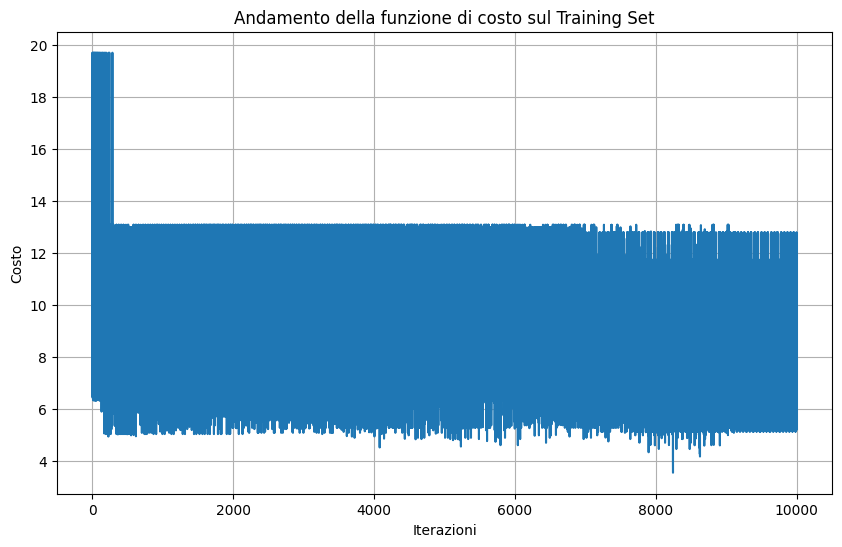

In [104]:
# Istanziazione del modello
logistic_model = LogisticRegression(learning_rate=0.01, n_iterations=10000)
# Addestramento del modello
logistic_model.fit(X_train, y_train)
# Visualizzazione dell'andamento della funzione di costo
logistic_model.plot_cost_history()

### Normalizziamo

Perchè adesso?
Prima puliamo i dati (feature costanti, ridondanti).

Poi selezioniamo le feature più informative.

Solo dopo normalizziamo per addestrare il modello.

In [105]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Avvio addestramento...
Iterazione 0: Costo train = 0.680988
Iterazione 100: Costo train = 0.438139
Iterazione 200: Costo train = 0.396642
Iterazione 300: Costo train = 0.375633
Iterazione 400: Costo train = 0.362251
Iterazione 500: Costo train = 0.352742
Iterazione 600: Costo train = 0.345520
Iterazione 700: Costo train = 0.339778
Iterazione 800: Costo train = 0.335055
Iterazione 900: Costo train = 0.331068
Iterazione 1000: Costo train = 0.327633
Iterazione 1100: Costo train = 0.324624
Iterazione 1200: Costo train = 0.321953
Iterazione 1300: Costo train = 0.319558
Iterazione 1400: Costo train = 0.317389
Iterazione 1500: Costo train = 0.315411
Iterazione 1600: Costo train = 0.313596
Iterazione 1700: Costo train = 0.311920
Iterazione 1800: Costo train = 0.310365
Iterazione 1900: Costo train = 0.308917
Iterazione 2000: Costo train = 0.307562
Iterazione 2100: Costo train = 0.306290
Iterazione 2200: Costo train = 0.305092
Iterazione 2300: Costo train = 0.303960
Iterazione 2400: Costo train 

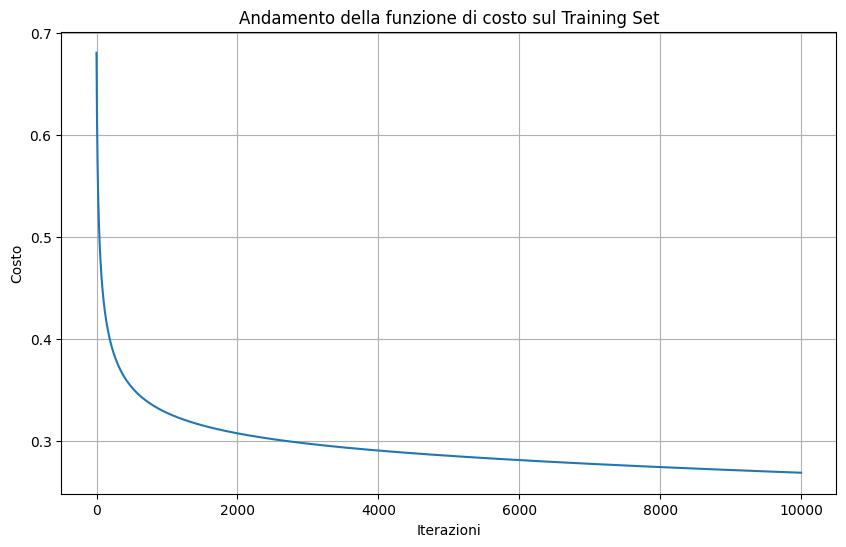

In [106]:
# Istanziazione del modello
logistic_model = LogisticRegression(learning_rate=0.01, n_iterations=10000)
# Addestramento del modello
logistic_model.fit(X_train, y_train)
# Visualizzazione dell'andamento della funzione di costo
logistic_model.plot_cost_history()

Costo sul test set: 0.308474


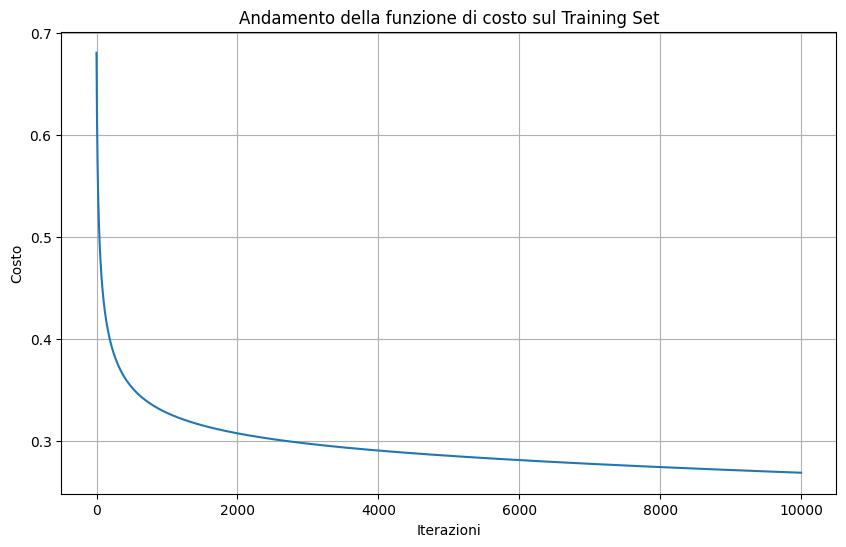

In [107]:
test_cost = logistic_model.compute_cost(X_test, y_test, logistic_model.weights)
print(f"Costo sul test set: {test_cost:.6f}")

# Visualizza il grafico del costo sul test set
logistic_model.plot_cost_history()

In [108]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predizione sui dati di test
y_pred = logistic_model.predict(X_test)
# Calcolo dell'accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy sul test set: {accuracy:.4f}")

Accuracy sul test set: 0.8944


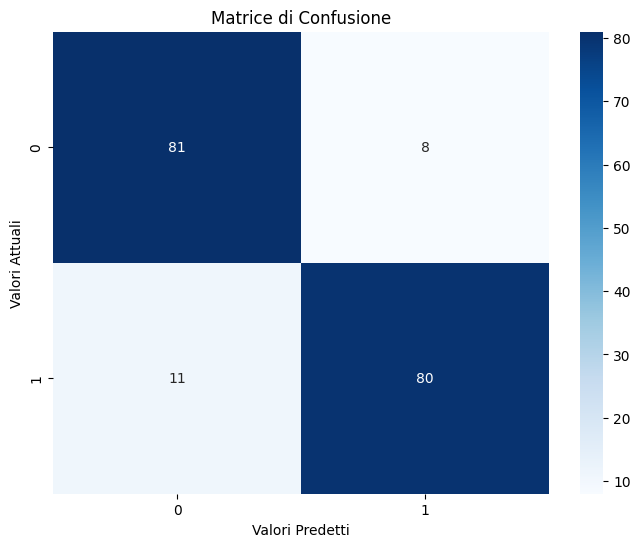

Accuracy: 0.8944
Precision: 0.9091
Recall: 0.8791
F1-score: 0.8939


In [109]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

# Predizione sui dati di test
y_pred = logistic_model.predict(X_test)
# Calcolo della matrice di confusione
cm = confusion_matrix(y_test, y_pred)
# Visualizzazione della matrice di confusione
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('Valori Attuali')
plt.xlabel('Valori Predetti')
plt.show()

# Calcolo delle metriche di valutazione
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9278
Precision: 0.9756
Recall: 0.8791
F1-score: 0.9249


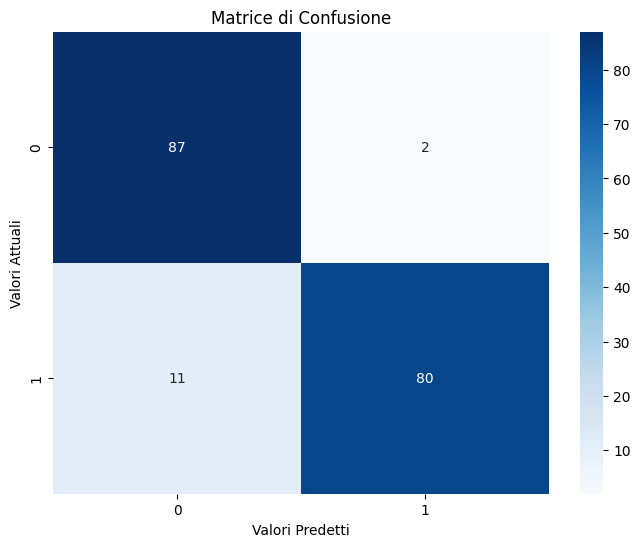

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

import matplotlib.pyplot as plt

# Inizializza il modello di Regressione Logistica
logistic_model = LogisticRegression(random_state=42)

# Addestra il modello
logistic_model.fit(X_train, y_train)

# Effettua le predizioni sul set di test
y_pred = logistic_model.predict(X_test)

# Calcola e stampa le metriche di valutazione
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Calcola e visualizza la matrice di confusione
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('Valori Attuali')
plt.xlabel('Valori Predetti')
plt.show()

### Siamo sicuri di aver tenuto le colonne migliori? Ne abbiamo tagliato troppo? o troppo poche?